Import Libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Dataset Paths

In [2]:
# Setup local paths
train_image_path = r"C:\Users\user\Documents\data\raw\KITTI\training\image_2"
train_label_path = r"C:\Users\user\Documents\data\raw\KITTI\training\label_2"

Get Image Files

In [12]:
image_files = [f for f in os.listdir(train_image_path) if f.endswith((".png", ".jpg", ".jpeg"))]

Read Label Files

In [13]:
all_objects = []

for label_file in os.listdir(train_label_path):
    
    if not label_file.endswith(".txt"):
        continue
        
    file_path = os.path.join(train_label_path, label_file)
    
    with open(file_path, "r") as f:
        lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            
            obj_class = parts[0]
            truncated = float(parts[1])
            occluded = int(parts[2])
            
            xmin = float(parts[4])
            ymin = float(parts[5])
            xmax = float(parts[6])
            ymax = float(parts[7])
            
            all_objects.append({
                "image": label_file.replace(".txt", ""),
                "class": obj_class,
                "truncated": truncated,
                "occluded": occluded,
                "xmin": xmin,
                "ymin": ymin,
                "xmax": xmax,
                "ymax": ymax
            })

Create DataFrame

In [14]:
df_labels = pd.DataFrame(all_objects)
df_labels.head()

,image,class,truncated,occluded,xmin,ymin,xmax,ymax
0,000000,Pedestrian,0.0,0,712.40,143.00,810.73,307.92
1,000001,Truck,0.0,0,599.41,156.40,629.75,189.25
2,000001,Car,0.0,0,387.63,181.54,423.81,203.12
3,000001,Cyclist,0.0,3,676.60,163.95,688.98,193.93
4,000001,DontCare,-1.0,-1,503.89,169.71,590.61,190.13


Bounding Box Features

In [15]:
df_labels["bbox_width"] = df_labels["xmax"] - df_labels["xmin"]
df_labels["bbox_height"] = df_labels["ymax"] - df_labels["ymin"]
df_labels["bbox_area"] = df_labels["bbox_width"] * df_labels["bbox_height"]

Dataset Statistics

In [16]:
stats = {
    "Total Images": len(image_files),
    "Total Annotations": len(df_labels),
    "Average Objects per Image": round(len(df_labels) / len(image_files), 2)
}

pd.DataFrame(stats, index=["Value"])

,Total Images,Total Annotations,Average Objects per Image
Value,7481,51865,6.93


Class Distribution

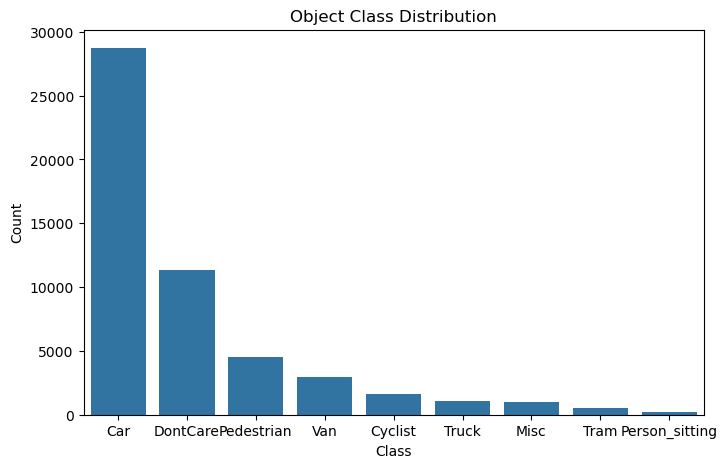

In [17]:
class_counts = df_labels["class"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Object Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

Bounding Box Width vs Height

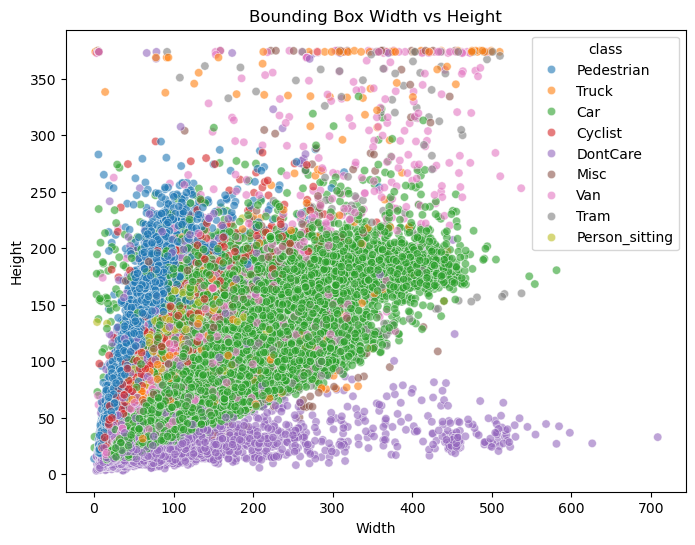

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_labels,
    x="bbox_width",
    y="bbox_height",
    hue="class",
    alpha=0.6
)

plt.title("Bounding Box Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

Occlusion Distribution

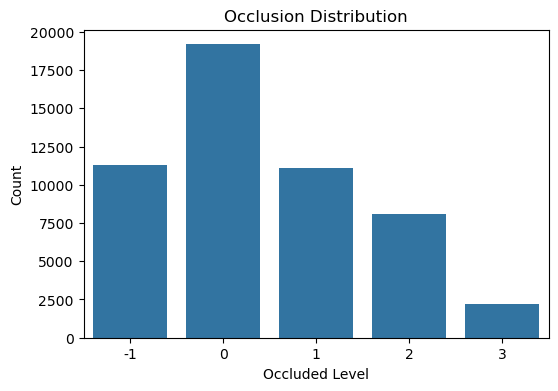

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_labels,
    x="occluded"
)

plt.title("Occlusion Distribution")
plt.xlabel("Occluded Level")
plt.ylabel("Count")

plt.show()

Truncation Distribution

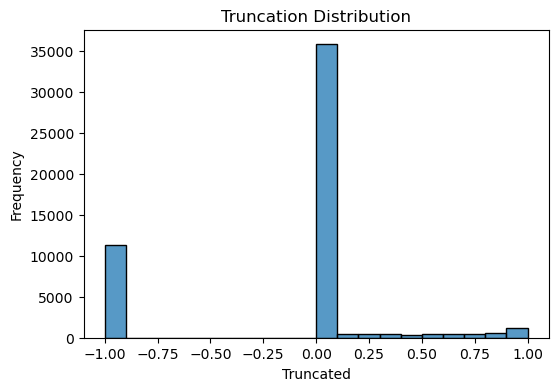

In [20]:
plt.figure(figsize=(6,4))

sns.histplot(
    df_labels["truncated"],
    bins=20
)

plt.title("Truncation Distribution")
plt.xlabel("Truncated")
plt.ylabel("Frequency")

plt.show()

Bounding Box Size by Class

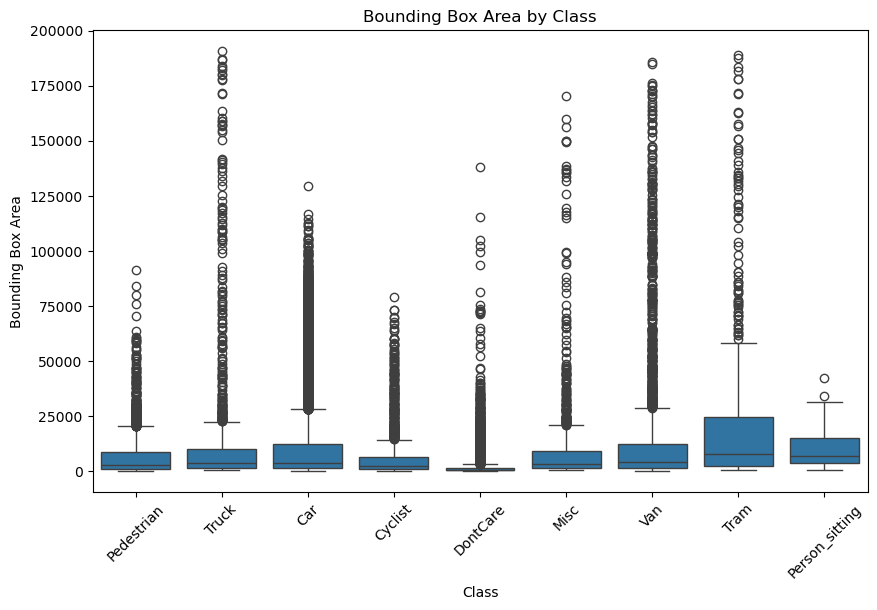

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_labels,
    x="class",
    y="bbox_area"
)

plt.title("Bounding Box Area by Class")
plt.xlabel("Class")
plt.ylabel("Bounding Box Area")

plt.xticks(rotation=45)

plt.show()

In [22]:
!jupyter nbconvert --to script "Dataset Exploration & Statistical Analysis.ipynb"

[NbConvertApp] Converting notebook Dataset Exploration & Statistical Analysis.ipynb to script
[NbConvertApp] Writing 3460 bytes to Dataset Exploration & Statistical Analysis.py
